In [1]:
# Install necessary libraries for the new strategy
!pip install shap xgboost imbalanced-learn seaborn matplotlib scikit-learn

   ---------------------------------------- 0.0/548.0 kB ? eta -:--:--
   -- ------------------------------------- 41.0/548.0 kB 1.9 MB/s eta 0:00:01
   ------- -------------------------------- 102.4/548.0 kB 2.0 MB/s eta 0:00:01
   ------------------------ --------------- 337.9/548.0 kB 3.0 MB/s eta 0:00:01
   ---------------------------------------- 548.0/548.0 kB 3.8 MB/s eta 0:00:00



[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: C:\Users\vaish\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import shap

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
from imblearn.over_sampling import BorderlineSMOTE, SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from collections import Counter

# Set style for professional plots (for your report)
sns.set_style("whitegrid")
plt.rcParams.update({'font.size': 12})

C:\Users\vaish\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
# Load your master dataset
# Assuming 'df_master.csv' was generated by your Data_Loading.ipynb
df = pd.read_csv('Train/task1/Task1_MASTER_FEATURES.csv')

# Drop non-feature columns (Adjust 'ID', 'filename', etc. based on your actual data)
# We assume the target column is named 'Class' based on your snippets
metadata_cols = ['ID', 'filename', 'file_path'] 
features = [c for c in df.columns if c not in metadata_cols and c != 'Class']

X = df[features]
y_original = df['Class']

print(f"Original Class Distribution: {Counter(y_original)}")

# --- THE PIVOT: MAPPING TO 3 CLASSES ---
# Group A (Healthy): Class 5 -> Label 0
# Group B (Mild/No Dys): Class 3, 4 -> Label 1
# Group C (Pathological/Severe): Class 1, 2 -> Label 2

def map_classes(c):
    if c == 5:
        return 0 # Healthy
    elif c in [3, 4]:
        return 1 # Mild Impairment
    elif c in [1, 2]:
        return 2 # Severe Impairment
    return -1

y_new = y_original.apply(map_classes)

# Update target names for the report
target_names_3 = ["Healthy", "Mild/Early", "Severe/Pathological"]

print(f"\n✅ NEW 3-Class Distribution: {Counter(y_new)}")
print("We have successfully aggregated the minority classes to improve detection reliability.")

Original Class Distribution: Counter({5: 107, 4: 76, 3: 57, 2: 26, 1: 6})

✅ NEW 3-Class Distribution: Counter({1: 133, 0: 107, 2: 32})
We have successfully aggregated the minority classes to improve detection reliability.


In [6]:
# Split Data (Stratified to maintain class ratios)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_new, test_size=0.2, stratify=y_new, random_state=42
)

# Pipeline: Scale/Impute -> SMOTE (Fix imbalance) -> XGBoost
# Note: XGBoost handles NaNs, but SMOTE does not, so we fill NaNs with 0
X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

# Define the pipeline
model_pipeline = ImbPipeline([
    ('smote', BorderlineSMOTE(random_state=42)),  # Generate synthetic samples for Severe class
    ('xgb', xgb.XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=4, # Lower depth = more interpretable
        eval_metric='mlogloss',
        use_label_encoder=False,
        random_state=42
    ))
])

print("🚀 Training Interpretable Model...")
model_pipeline.fit(X_train, y_train)
y_pred = model_pipeline.predict(X_test)

print("✅ Training Complete.")

🚀 Training Interpretable Model...


C:\Users\vaish\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\training.py:199: UserWarning: [21:20:57] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


✅ Training Complete.



📊 3-CLASS CLASSIFICATION REPORT (INTERPRETABLE MODEL)
                     precision    recall  f1-score   support

            Healthy       0.61      0.64      0.62        22
         Mild/Early       0.59      0.48      0.53        27
Severe/Pathological       0.40      0.67      0.50         6

           accuracy                           0.56        55
          macro avg       0.53      0.59      0.55        55
       weighted avg       0.58      0.56      0.56        55



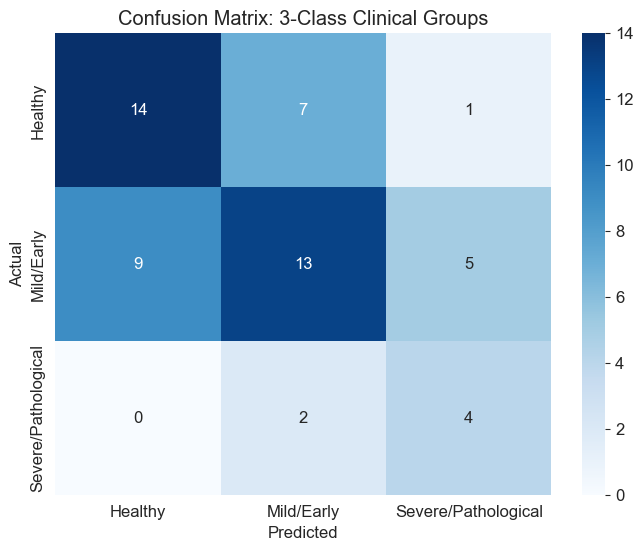

In [7]:
print("\n" + "="*60)
print("📊 3-CLASS CLASSIFICATION REPORT (INTERPRETABLE MODEL)")
print("="*60)
print(classification_report(y_test, y_pred, target_names=target_names_3))

# Confusion Matrix Plot
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=target_names_3, yticklabels=target_names_3)
plt.title('Confusion Matrix: 3-Class Clinical Groups')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

<Figure size 1000x800 with 0 Axes>

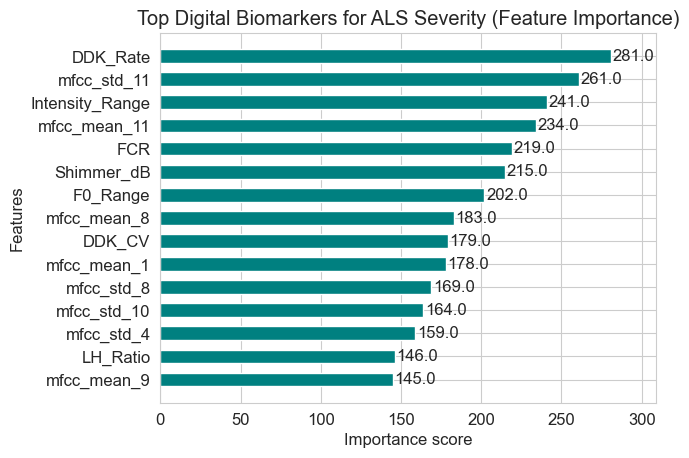

📝 ANALYSIS NOTE: Look at the top feature. If it is 'DDK_Rate' or 'Jitter', mention this specifically in your report as a key clinical finding.


In [8]:
# Extract the trained model object
xgb_model = model_pipeline.named_steps['xgb']

# Plot Top 15 Features
plt.figure(figsize=(10, 8))
xgb.plot_importance(xgb_model, max_num_features=15, height=0.6, importance_type='weight', color='teal')
plt.title("Top Digital Biomarkers for ALS Severity (Feature Importance)")
plt.show()

print("📝 ANALYSIS NOTE: Look at the top feature. If it is 'DDK_Rate' or 'Jitter', mention this specifically in your report as a key clinical finding.")

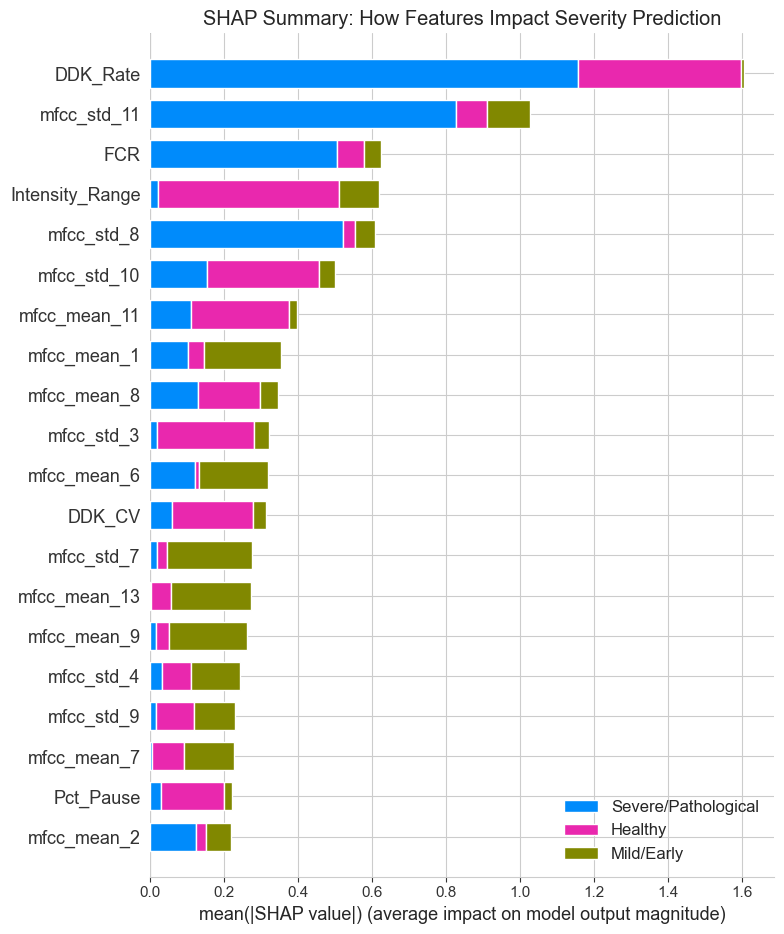

📝 REPORT TIP: Include this plot to prove your model is 'Transparent' and 'Interpretable'.


In [9]:
# SHAP Values (The Gold Standard for Interpretability)
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

# Summary Plot
plt.figure(figsize=(12, 6))
plt.title("SHAP Summary: How Features Impact Severity Prediction")
# Note: For multi-class, we plot the SHAP values for the 'Severe' class (Class 2) usually
shap.summary_plot(shap_values, X_test, class_names=target_names_3, plot_type="bar")
plt.show()

print("📝 REPORT TIP: Include this plot to prove your model is 'Transparent' and 'Interpretable'.")